# Larger-than-memory OME-Zarr processing

Generates a larger-than-memory synthetic volume, stores it on disk as OME-Zarr, and then filters and segments it chunk-wise with Dask under a fixed memory budget before saving the result back to disk.

In [1]:
import time
import os
import re
import dask
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import psutil
import qim3d
import qim3d.io 
from dask.distributed import Client
from dask_image.ndfilters import gaussian_filter
from skimage.filters import threshold_otsu

The generated data and dask configuration can be specified below.

In [ ]:
TILE_SHAPE = (300, 300, 300)  # one synthetic block, generated in memory
N_TILES = (11, 11, 11)        # nearest-neighbour stretch factor (z, y, x)
CHUNK_SIZE = 300              # edge length of one OME-Zarr chunk (cube), in voxels

N_WORKERS = 8                 # dask worker count, at maximum equal CPU core count
MEMORY_LIMIT = '4GB'          # per worker allocation

MEMORY_BUDGET = N_WORKERS * int(re.sub(r"\D", "", MEMORY_LIMIT))

INPUT_PATH = 'large_volume.zarr'
OUTPUT_PATH = 'large_volume_segmented.zarr'
LOCAL_DIRECTORY = os.path.abspath('dask-worker-space') # folder for temporary dask files

volume_shape = tuple(tile * n for tile, n in zip(TILE_SHAPE, N_TILES))
volume_bytes = int(np.prod(volume_shape))

print(f'Volume shape .....: {volume_shape}')
print(f'Uncompressed size : {volume_bytes / 1e9:.2f} GB')
print(f'Worker memory budget: {MEMORY_BUDGET :.2f} GB')
print(f'Dataset is {volume_bytes / MEMORY_BUDGET /1e7:.2f}% of the budget')

Volume shape .....: (3300, 3300, 3300)
Uncompressed size : 35.94 GB
Worker memory budget: 32.00 GB
Dataset is 112.30% of the budget


In [3]:
client = Client(n_workers=N_WORKERS, threads_per_worker=1, memory_limit=MEMORY_LIMIT, local_directory=LOCAL_DIRECTORY)

In [4]:
dask.config.set(scheduler=client)

budget = sum(w['memory_limit'] for w in client.scheduler_info()['workers'].values())
print(f'Worker memory budget : {budget / 1e9:.2f} GB')
print(f'Dataset is {volume_bytes / budget*100:.2f}% the budget')

Worker memory budget : 20.00 GB
Dataset is 179.69% the budget


In [5]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 8,Total memory: 29.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45947,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41935,Total threads: 1
Dashboard: http://127.0.0.1:32805/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:46651,


Only one tile is generated in memory using numpy, then it's stretched to the full volume shape with nearest-neighbour upsampling in dask. Noise is added using dask (to make compression more difficult for showcase purposes)

Tile: (300, 300, 300), uint8, 27 MB in memory


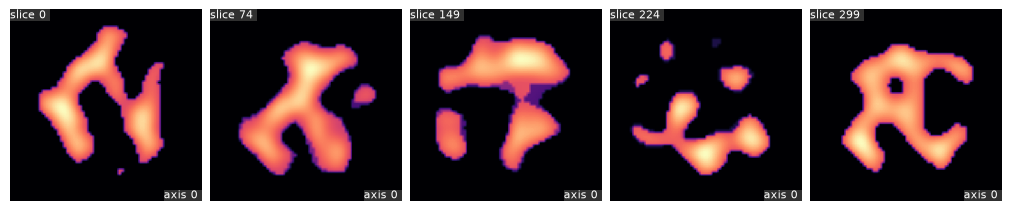

In [6]:
tile = qim3d.generate.volume(
    base_shape=(64, 64, 64),
    final_shape=TILE_SHAPE,
    shape='cylinder',
    axis=0,
    noise_scale=0.08,
    threshold=0.55,
    decay_rate=4,
    gamma=0.9,
    seed=3,
)

print(f'Tile: {tile.shape}, {tile.dtype}, {tile.nbytes / 1e6:.0f} MB in memory')
qim3d.viz.slices_grid(tile, n_slices=5)

In [7]:
qim3d.viz.slicer_orthogonal(tile)

In [8]:
volume = da.from_array(tile, chunks=CHUNK_SIZE)
for axis, factor in enumerate(N_TILES):
    volume = da.repeat(volume, factor, axis=axis)  # nearest-neighbour stretch

noise = da.random.default_rng(seed=0).integers(
    0, 30, size=volume.shape, dtype='uint8', chunks=volume.chunks
)
volume = da.clip(volume.astype('uint16') + noise, 0, 255).astype('uint8')

print(f'Chunk shape : {volume.chunksize}')
print(f'Chunk count : {volume.npartitions}')
volume

Chunk shape : (330, 330, 330)
Chunk count : 1000


dask.array<astype, shape=(3300, 3300, 3300), dtype=uint8, chunksize=(330, 330, 330), chunktype=numpy.ndarray>

`qim3d.io.export_ome_zarr` accepts a Dask array and streams it to disk chunk by chunk

In [9]:
t0 = time.time()
qim3d.io.export_ome_zarr(INPUT_PATH, volume, chunk_size=CHUNK_SIZE, replace=True)
print(f'Written in {time.time() - t0:.0f} s')

Exporting data to OME-Zarr format at large_volume.zarr
Number of scales: 5

Input data will be rechunked
 - shape...: (3300, 3300, 3300)
 - chunks..: (300, 300, 300)

Calculating the multi-scale pyramid
- Scale 0: (3300, 3300, 3300)
- Scale 1: (1650, 1650, 1650)
- Scale 2: (825, 825, 825)
- Scale 3: (412, 412, 412)
- Scale 4: (206, 206, 206)
Writing data to disk


Saving:   0%|          | 0.00/1.58k [00:00<?, ?Chunks/s]

/home/ankov/miniconda3/envs/qim3d-stable-base/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning:

Sending large graph of size 29.12 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.


All done!


Written in 734 s


`load=False` returns a Dask array

In [10]:
vol = qim3d.io.import_ome_zarr(INPUT_PATH, scale=0, load=False)

print(f'Shape ........: {vol.shape}')
print(f'Chunks .......: {vol.chunksize}')
print(f'Size in memory: {vol.nbytes / 1e9:.2f} GB (if it were ever loaded)')
vol

Data contains 5 scales:
- Scale 0: (3300, 3300, 3300)
- Scale 1: (1650, 1650, 1650)
- Scale 2: (825, 825, 825)
- Scale 3: (412, 412, 412)
- Scale 4: (206, 206, 206)

Loading scale 0 with shape (3300, 3300, 3300)


Shape ........: (3300, 3300, 3300)
Chunks .......: (300, 300, 300)
Size in memory: 35.94 GB (if it were ever loaded)


dask.array<from-zarr, shape=(3300, 3300, 3300), dtype=uint8, chunksize=(300, 300, 300), chunktype=numpy.ndarray>

Any scale can be loaded into memory. This time it is the lowest.

Data contains 5 scales:
- Scale 0: (3300, 3300, 3300)
- Scale 1: (1650, 1650, 1650)
- Scale 2: (825, 825, 825)
- Scale 3: (412, 412, 412)
- Scale 4: (206, 206, 206)

Loading scale 4 with shape (206, 206, 206)


Preview: (206, 206, 206), 69.9 MB in memory


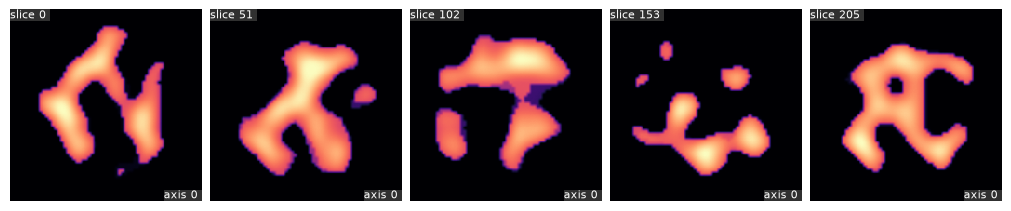

In [11]:
preview = qim3d.io.import_ome_zarr(INPUT_PATH, scale='lowest', load=True)

print(f'Preview: {preview.shape}, {preview.nbytes / 1e6:.1f} MB in memory')
qim3d.viz.slices_grid(preview, n_slices=5)

for a closer inspection, use `qim3d.viz.chunks`

In [12]:
qim3d.viz.chunks(INPUT_PATH)

The in-memory lowest scale can be used to determine a good threshold.

Subsampled volume has size 100% of the original volume.


Otsu threshold from the (206, 206, 206) preview: 99.1


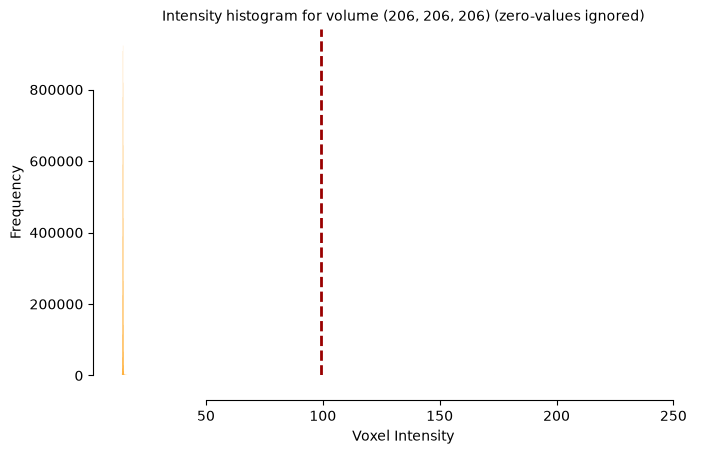

<Axes: title={'center': 'Intensity histogram for volume (206, 206, 206) (zero-values ignored)'}, xlabel='Voxel Intensity', ylabel='Frequency'>

In [13]:
threshold = threshold_otsu(preview)
print(f'Otsu threshold from the {preview.shape} preview: {threshold:.1f}')

qim3d.viz.histogram(preview, vertical_line=threshold)

Then smooth, threshold and segment the larger-than-memory dask volume.

In [14]:
smoothed = gaussian_filter(vol.astype('float32'), sigma=2.0)

mask = (smoothed > threshold).astype('uint8')

# map_overlap adds the halo the median filter needs, then trims it away again
cleaned = da.map_overlap(
    lambda block: qim3d.filters.median(block, size=3),
    mask,
    depth=2,
    boundary='reflect',
    dtype='uint8',
)

segmented = (cleaned * 255).astype('uint8')

print(f'{len(segmented.__dask_graph__())} tasks queued, nothing computed yet')
segmented

103778 tasks queued, nothing computed yet


dask.array<mul, shape=(3300, 3300, 3300), dtype=uint8, chunksize=(300, 300, 300), chunktype=numpy.ndarray>

In [15]:
rss_before = psutil.Process().memory_info().rss

t0 = time.time()
qim3d.io.export_ome_zarr(OUTPUT_PATH, segmented, chunk_size=CHUNK_SIZE, replace=True)
elapsed = time.time() - t0

rss_after = psutil.Process().memory_info().rss

print(f'Processed and written in {elapsed:.0f} s')
print(f'Notebook memory: {rss_before / 1e6:.0f} MB -> {rss_after / 1e6:.0f} MB, '
      f'for a {vol.nbytes / 1e9:.2f} GB volume')

Exporting data to OME-Zarr format at large_volume_segmented.zarr
Number of scales: 5

Input data will be rechunked
 - shape...: (3300, 3300, 3300)
 - chunks..: (300, 300, 300)

Calculating the multi-scale pyramid
- Scale 0: (3300, 3300, 3300)
- Scale 1: (1650, 1650, 1650)
- Scale 2: (825, 825, 825)
- Scale 3: (412, 412, 412)
- Scale 4: (206, 206, 206)
Writing data to disk


Saving:   0%|          | 0.00/1.58k [00:00<?, ?Chunks/s]

/home/ankov/miniconda3/envs/qim3d-stable-base/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning:

Sending large graph of size 11.55 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.


All done!


Processed and written in 2761 s
Notebook memory: 1043 MB -> 1551 MB, for a 35.94 GB volume


Data contains 5 scales:
- Scale 0: (3300, 3300, 3300)
- Scale 1: (1650, 1650, 1650)
- Scale 2: (825, 825, 825)
- Scale 3: (412, 412, 412)
- Scale 4: (206, 206, 206)

Loading scale 4 with shape (206, 206, 206)
Data contains 5 scales:
- Scale 0: (3300, 3300, 3300)
- Scale 1: (1650, 1650, 1650)
- Scale 2: (825, 825, 825)
- Scale 3: (412, 412, 412)
- Scale 4: (206, 206, 206)

Loading scale 4 with shape (206, 206, 206)


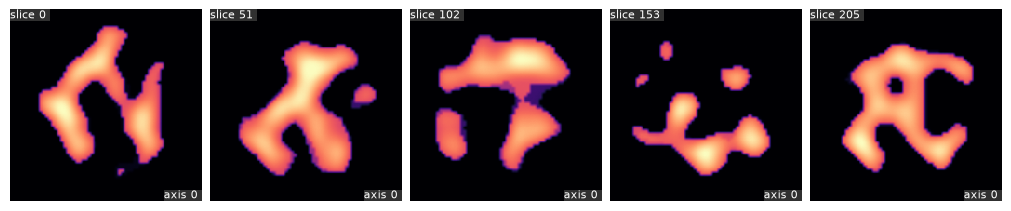

In [16]:
before = qim3d.io.import_ome_zarr(INPUT_PATH, scale='lowest', load=True)
after = qim3d.io.import_ome_zarr(OUTPUT_PATH, scale='lowest', load=True)

qim3d.viz.slices_grid(before, n_slices=5)

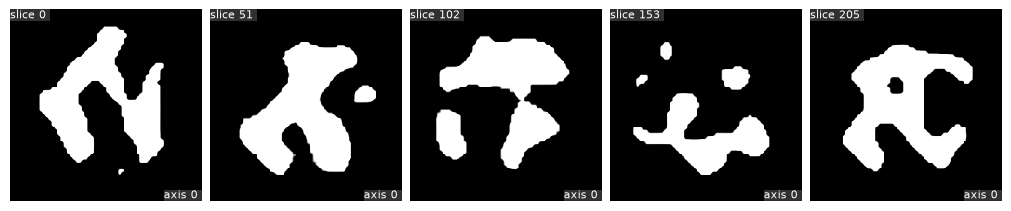

In [17]:
qim3d.viz.slices_grid(after, n_slices=5, colormap='gray')

`qim3d.viz.compare_volumes` puts the two volumes side by side with a difference map and a slider to move through the stack.

In [18]:
qim3d.viz.compare_volumes(before, after)

A preview can hide small errors, so it is worth checking one slice at full resolution. Indexing a lazy array reads only the chunks that the slice touches, which is a few hundred megabytes off disk rather than the whole volume.

Data contains 5 scales:
- Scale 0: (3300, 3300, 3300)
- Scale 1: (1650, 1650, 1650)
- Scale 2: (825, 825, 825)
- Scale 3: (412, 412, 412)
- Scale 4: (206, 206, 206)

Loading scale 0 with shape (3300, 3300, 3300)


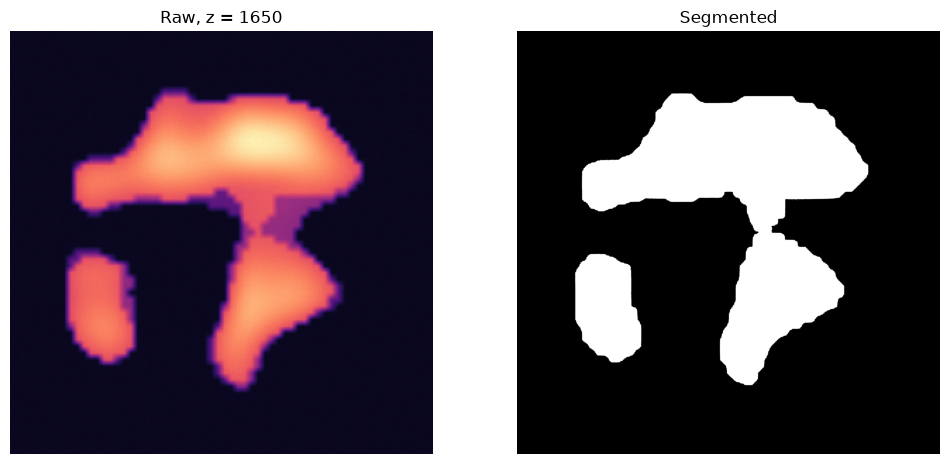

Returned 21.8 MB from a 35.94 GB dataset


In [19]:
segmented_on_disk = qim3d.io.import_ome_zarr(OUTPUT_PATH, scale=0, load=False)

z = vol.shape[0] // 2
raw_slice = np.asarray(vol[z])
seg_slice = np.asarray(segmented_on_disk[z])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw_slice, cmap='magma')
axes[0].set_title(f'Raw, z = {z}')
axes[1].imshow(seg_slice, cmap='gray')
axes[1].set_title('Segmented')
for ax in axes:
    ax.axis('off')
plt.show()

print(f'Returned {(raw_slice.nbytes + seg_slice.nbytes) / 1e6:.1f} MB '
      f'from a {vol.nbytes / 1e9:.2f} GB dataset')

Remember to shut down the cluster in the end as a good practice.


In [20]:
client.close()